## Phase 2 - Classification des documents et des requetes 

## ___________________________________________________________________________________________

## 1.1 Choix du modèle :

## -- 

In [50]:
# imports
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
)
from sklearn.model_selection import train_test_split

print ('All imports successful!')

All imports successful!


In [51]:
# Load the dataset
with open ('data/retrieval-engine-competition/docs.json', 'r', encoding='utf-8') as f:
    docs = json.load(f)

with open ('data/retrieval-engine-competition/queries_train.json', 'r', encoding='utf-8') as f:
    queries_train = json.load(f)

with open ('data/retrieval-engine-competition/qgts_train.json', 'r', encoding='utf-8') as f:
    relevance_raw = json.load(f)

print(f'Number of documents : {len(docs)}')
print(f'Number of requests : {len(queries_train)}')
print(f'Number of relevances : {len(relevance_raw)}')

Number of documents : 216041
Number of requests : 327
Number of relevances : 327


In [53]:
# Explain a file structure relevance 
# Fix ground_truth
ground_truth = {}
for query_id, data in relevance_raw.items():
    ground_truth[query_id] = [
        item['doc_id'] for item in data['relevant_doc_ids']
    ]

# Test
first_ids = list(ground_truth.keys())[0]
print(f' Number of requests     : {len(ground_truth)}')
print(f' query_ids              : {first_ids}')
print(f' Docs relevants        : {ground_truth[first_ids][:3]}')
print(f' Type                   : {type(ground_truth[first_ids][0])}')

 Number of requests     : 327
 query_ids              : 961c4349-8cf1-4ef1-89cc-24d20bb9d000_67878
 Docs relevants        : ['135f5fdb-bcba-40b8-b90d-823617f1e805_21141', 'd0609dab-fbf2-4838-be6a-05e76b291258_30322', 'cccd8617-6417-44a5-9f67-d4b7001b7165_47263']
 Type                   : <class 'str'>


In [54]:
def make_content(item):
    title = item.get('title', '') or ''
    text = item.get('text', '') or ''
    tags = ' '.join(item.get('tags', []) or [])
    return f'{title} {text} {tags}'.strip()

for doc in docs:
    doc['content'] = make_content(doc)

for q in queries_train:
    q['content'] = make_content(q)

# Create DataFrames
df_docs = pd.DataFrame(docs)
df_queries = pd.DataFrame(queries_train)

print(f' Column of documents :{list(df_docs.columns)}')
print(f' Column of queries   :{list(df_queries.columns)}')

 Column of documents :['id', 'text', 'title', 'tags', 'category', 'content']
 Column of queries   :['id', 'text', 'title', 'tags', 'category', 'content']


 Number of category : 5
 Category           : ['android', 'gaming', 'programmers', 'tex', 'unix']

Distribution (docs) :
tex            68184
unix           47382
gaming         45301
programmers    32176
android        22998
Name: count, dtype: int64


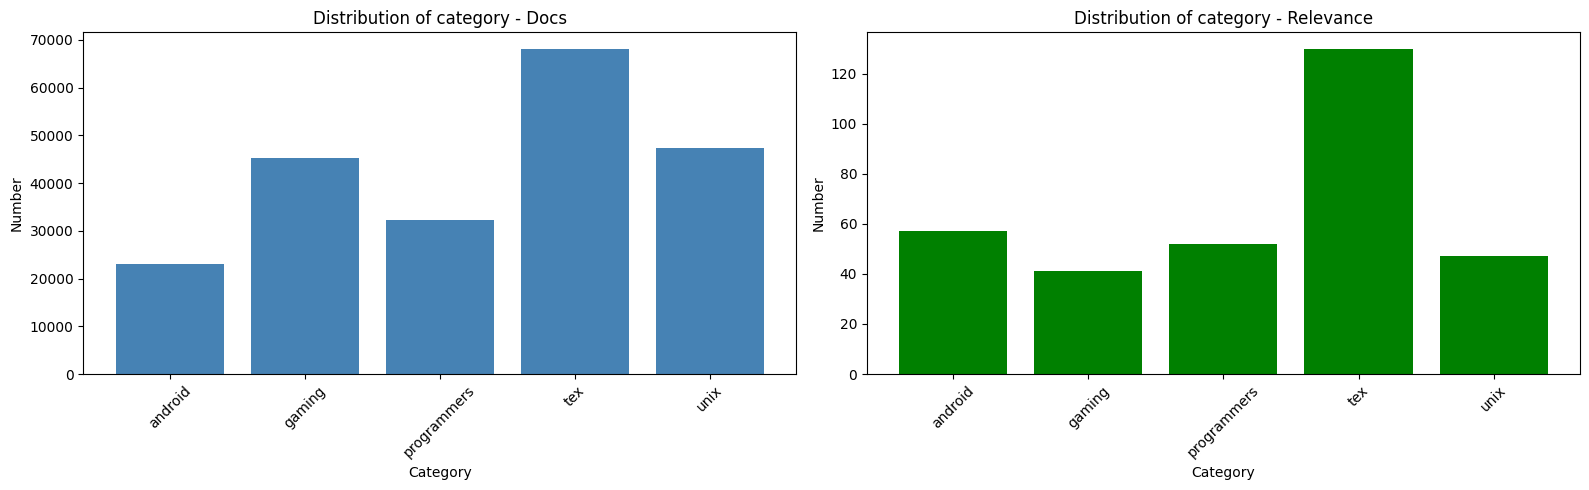

In [56]:
# Category distribution
doc_labels = df_docs['category'].tolist()
query_labels = df_queries['category'].tolist()
category = sorted(set(doc_labels))

print(f' Number of category : {len(category)}')
print(f' Category           : {category}')
print()
print('Distribution (docs) :')
print(pd.Series(doc_labels).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

doc_counts = pd.Series(doc_labels).value_counts().sort_index()
axes[0].bar(doc_counts.index, doc_counts.values, color='steelblue')
axes[0].set_title('Distribution of category - Docs')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number')
axes[0].tick_params(axis='x', rotation=45)

q_counts = pd.Series(query_labels).value_counts().sort_index()
axes[1].bar(q_counts.index, q_counts.values, color='green')
axes[1].set_title('Distribution of category - Relevance')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number')
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

## 1.2 Données d'entrainement

In [57]:
# vectors TF-IDF
doc_contents    = df_docs['content'].tolist()
query_contents  = df_queries['content'].tolist()

tfidf_clf   = TfidfVectorizer(max_features=10000, sublinear_tf=True)
X_docs      = tfidf_clf.fit_transform(doc_contents)
X_queries   = tfidf_clf.transform(query_contents)

print(f' Shape X_docs       :{X_docs.shape}')
print(f' Shape X_queries    :{X_queries.shape}')

 Shape X_docs       :(216041, 10000)
 Shape X_queries    :(327, 10000)


## Training and Evaluation

In [58]:
# Train / Test split (80/20 laminate)
X_train, X_test, y_train, y_test = train_test_split(
    X_docs, doc_labels, 
    test_size = 0.2,
    random_state = 42,
    stratify = doc_labels
)
print(f' Train  : {X_train.shape[0]} documents')
print(f' Test   : {X_test.shape[0]} documents')

 Train  : 172832 documents
 Test   : 43209 documents


In [59]:
# Training
clf= LogisticRegression(
    max_iter = 1000,
    random_state = 42,
    solver = 'lbfgs',
    
)
# Training the model 
clf.fit(X_train, y_train)
print('Training model..OK')

Training model..OK


In [60]:
# Evaluation of documents
y_predicted_docs = clf.predict(X_test)
acc_docs         = accuracy_score(y_test, y_predicted_docs)

print('==== EVALUATION IN DOCUMENTS ====')
print(f'Accuracy global : {acc_docs:.4f} ({acc_docs*100:.2f}%)')
print()
print('=' * 65)
print('CLASSIFICATION REPORT :')
print(classification_report(y_test, y_predicted_docs))
print('=' * 65)

==== EVALUATION IN DOCUMENTS ====
Accuracy global : 0.9822 (98.22%)

CLASSIFICATION REPORT :
              precision    recall  f1-score   support

     android       0.98      0.96      0.97      4600
      gaming       0.99      0.99      0.99      9060
 programmers       0.97      0.97      0.97      6435
         tex       0.99      0.99      0.99     13637
        unix       0.97      0.98      0.97      9477

    accuracy                           0.98     43209
   macro avg       0.98      0.98      0.98     43209
weighted avg       0.98      0.98      0.98     43209



In [61]:
# Evaluation of requests
y_predicted_queries = clf.predict(X_queries)
acc_queries         = accuracy_score(query_labels, y_predicted_queries)

print('==== EVALUATION IN QUERIES ====')
print(f'Accuracy global : {acc_queries:.4f} ({acc_queries*100:.2f}%)')
print()
print('=' * 65)
print('CLASSIFICATION REPORT :')
print(classification_report(query_labels, y_predicted_queries))
print('=' * 65)

==== EVALUATION IN QUERIES ====
Accuracy global : 0.9144 (91.44%)

CLASSIFICATION REPORT :
              precision    recall  f1-score   support

     android       1.00      0.51      0.67        57
      gaming       1.00      1.00      1.00        41
 programmers       1.00      1.00      1.00        52
         tex       1.00      1.00      1.00       130
        unix       0.63      1.00      0.77        47

    accuracy                           0.91       327
   macro avg       0.93      0.90      0.89       327
weighted avg       0.95      0.91      0.91       327



In [64]:
# Accuracy
print('=' * 50)
print(f'{"Accuracy Docs":<30} : {acc_docs:.4f}({acc_docs*100:.2f}%)')
print(f'{"Accuracy Requests":<30} : {acc_queries:.4f}({acc_queries*100:.2f}%)')
print(f'{"Difference":<30} : {abs(acc_docs - acc_queries):.4f}')
print('=' * 50)

Accuracy Docs                  : 0.9822(98.22%)
Accuracy Requests              : 0.9144(91.44%)
Difference                     : 0.0678


In [65]:
category = sorted(set(doc_labels))
print(f'Category :{category}')

Category :['android', 'gaming', 'programmers', 'tex', 'unix']


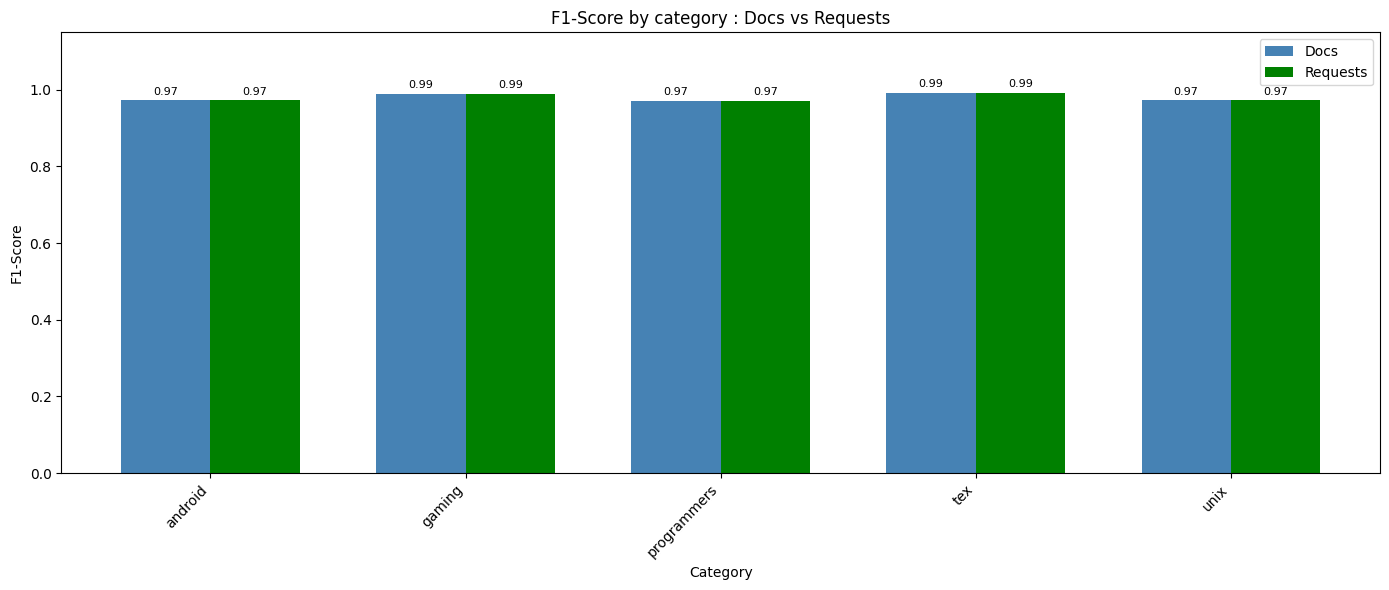

In [66]:
# Graph F1-Score by category : Docs / Requests
report_docs = classification_report(y_test, y_predicted_docs, output_dict=True)
report_queries = classification_report(query_labels, y_predicted_queries, output_dict=True)

f1_docs= [report_docs.get(c, {}).get('f1-score', 0) for c in category]
f1_queries= [report_docs.get(c, {}).get('f1-score', 0) for c in category]

x = np.arange(len(category))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x-width/2, f1_docs, width, label='Docs', color='steelblue')
bars2 = ax.bar(x+width/2, f1_queries, width, label='Requests', color='green')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Category')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score by category : Docs vs Requests')
ax.set_xticks(x)
ax.set_xticklabels(category, rotation=46, ha='right')
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

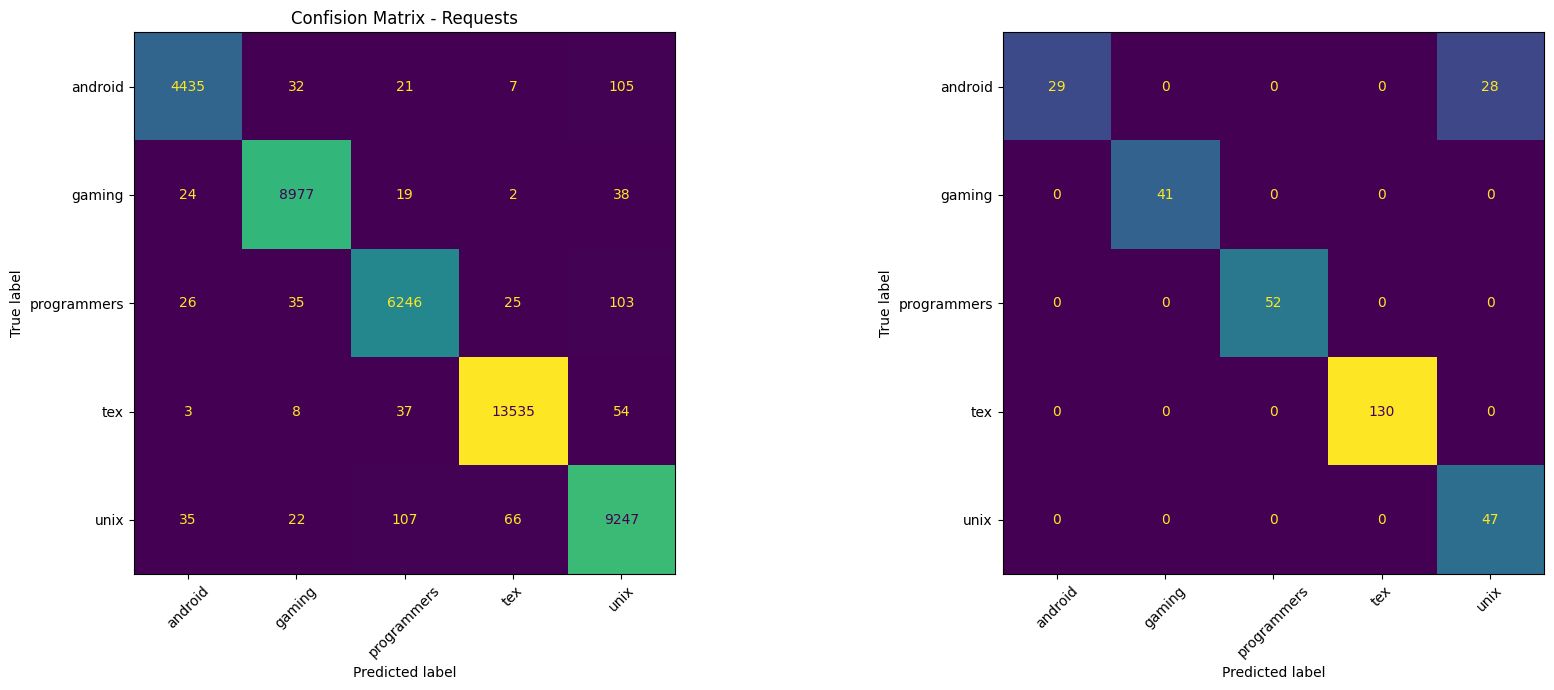

In [67]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm_docs = confusion_matrix(y_test, y_predicted_docs, labels=category)
ConfusionMatrixDisplay(cm_docs, display_labels=category).plot(
    ax=axes[0], xticks_rotation=45, colorbar=False)
axes[0].set_title('Confision Matrix - Documents')

cm_queries = confusion_matrix(query_labels, y_predicted_queries, labels=category)
ConfusionMatrixDisplay(cm_queries, display_labels=category).plot(
    ax=axes[1], xticks_rotation=45, colorbar=False)
axes[0].set_title('Confision Matrix - Requests')

plt.tight_layout()
plt.show()

In [68]:
# Import and save the classifier for Phase 2
import pickle

with open('classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

with open('tfidf_clf.pkl', 'wb') as f:
    pickle.dump(tfidf_clf, f)

print('=' * 30)
print('Saved Classifier :')
print(' -> classifier.pkl (Logistic Regression Model)')
print(' -> tfidf_clf.pkl (TF-IDF)')
print('=' * 30)


Saved Classifier :
 -> classifier.pkl (Logistic Regression Model)
 -> tfidf_clf.pkl (TF-IDF)
